In [9]:
########## I M P O R T ##########
import os
import random
import wave
import sys
import json
import time
import copy
import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import soundfile as sf
import onnxruntime as ort
import numpy as np

In [10]:
########## C H E C K    G P U ##########
def check_gpu_status():
    cuda_available = torch.cuda.is_available()
    print(f"CUDA Available: {cuda_available}")

    if cuda_available:
        num_gpus = torch.cuda.device_count()
        print(f"Number of GPUs detected: {num_gpus}\n")
        for i in range(num_gpus):
            print(f"--- GPU {i} ---")
            print(f"Name: {torch.cuda.get_device_name(i)}")
            total_memory = torch.cuda.get_device_properties(i).total_memory / (1024**3)
            print(f"Total Memory: {total_memory:.2f} GB")
    else:
        print("PyTorch cannot detect a compatible GPU. It will default to CPU.")

check_gpu_status()

CUDA Available: True
Number of GPUs detected: 1

--- GPU 0 ---
Name: NVIDIA GeForce RTX 5070 Laptop GPU
Total Memory: 7.96 GB


In [11]:
########## C O N F I G ##########
sys.path.append(os.path.abspath('..'))
from Utils.config_loader import get_keywords, get_config_value

# 1. Configuration
def load_keywords():
    for p in ["config.json", "../config.json", "../../config.json"]:
        if os.path.exists(p):
            with open(p, "r") as f: return json.load(f).get("keywords", ["yes", "no", "up", "down"])
    return ["yes", "no", "up", "down"]

DATA_DIR = "../dataset/"
CLASSES = load_keywords()
TARGET_SAMPLE_RATE = get_config_value('target_sample_rate', 16000)
NUM_SAMPLES = get_config_value('num_samples', 16000)
BATCH_SIZE = 32
EPOCHS = 100  # Set high, early stopping will handle it
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Classes: {CLASSES}")
print(f"Device: {DEVICE}")

Classes: ['yes', 'no', 'up', 'down']
Device: cuda


In [12]:
########## D A T A S E T ##########
def get_files_and_labels():
    file_paths = []
    labels = []
    class_to_idx = {cls_name: i for i, cls_name in enumerate(CLASSES)}

    for cls_name in CLASSES:
        cls_dir = os.path.join(DATA_DIR, cls_name)
        if not os.path.exists(cls_dir):
            print(f"Warning: Directory not found: {cls_dir}")
            continue
        for file in os.listdir(cls_dir):
            if file.endswith(".wav"):
                file_paths.append(os.path.join(cls_dir, file))
                labels.append(class_to_idx[cls_name])

    return file_paths, labels

file_paths, labels = get_files_and_labels()
if not file_paths:
    print("Error: No files found! Check your DATA_DIR.")
else:
    train_paths, test_paths, train_labels, test_labels = train_test_split(
        file_paths, labels, test_size=0.2, stratify=labels, random_state=42
    )
    print(f"Dataset split: {len(train_paths)} train, {len(test_paths)} test")

Dataset split: 7588 train, 1898 test


In [13]:
########## C N N   E R S T E L L E N ##########
class KeywordDataset(Dataset):
    def __init__(self, paths, labels, is_training=False):
        self.paths = paths
        self.labels = labels
        self.is_training = is_training

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        clean_path = os.path.normpath(self.paths[idx])
        waveform_np, sr = sf.read(clean_path, dtype="float32")
        waveform = torch.from_numpy(waveform_np)

        if waveform.ndim == 1:
            waveform = waveform.unsqueeze(0)
        else:
            waveform = waveform.t()

        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        if self.is_training:
            # Augmented shift
            shift = random.randint(-1600, 1600)
            waveform = torch.roll(waveform, shift, dims=-1)

        if waveform.shape[1] > NUM_SAMPLES:
            waveform = waveform[:, :NUM_SAMPLES]
        elif waveform.shape[1] < NUM_SAMPLES:
            waveform = F.pad(waveform, (0, NUM_SAMPLES - waveform.shape[1]))

        return waveform, torch.tensor(self.labels[idx], dtype=torch.long)

class KeywordCNN(nn.Module):
    def __init__(self, num_classes):
        super(KeywordCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.fc1 = nn.Linear(128 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        logits = self.fc2(x)
        return logits

In [ ]:
########## T R A I N   &   M A I N ##########
def train_model(patience=7):
    train_loader = DataLoader(KeywordDataset(train_paths, train_labels, is_training=True), batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
    test_loader = DataLoader(KeywordDataset(test_paths, test_labels, is_training=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

    model = KeywordCNN(num_classes=len(CLASSES)).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    mfcc_transform = torchaudio.transforms.MFCC(
        sample_rate=TARGET_SAMPLE_RATE, n_mfcc=40, melkwargs={"n_mels": 64}
    ).to(DEVICE)
    
    freq_masking = torchaudio.transforms.FrequencyMasking(freq_mask_param=10).to(DEVICE)
    time_masking = torchaudio.transforms.TimeMasking(time_mask_param=20).to(DEVICE)

    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    early_stop_counter = 0

    # History lists for accuracy and loss
    history = {
        'train_loss': [], 'test_loss': [],
        'train_acc': [],  'test_acc': []
    }

    print(f"Training on {DEVICE}...")

    for epoch in range(EPOCHS):
        start_time = time.time()
        model.train()
        total_loss, correct, total = 0, 0, 0

        for batch_idx, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            with torch.no_grad():
                inputs = mfcc_transform(inputs)
                inputs = freq_masking(inputs)
                inputs = time_masking(inputs)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        train_acc = 100. * correct / total
        train_loss = total_loss / len(train_loader)

        model.eval()
        test_loss, test_correct, test_total = 0, 0, 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                inputs = mfcc_transform(inputs)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                test_total += targets.size(0)
                test_correct += predicted.eq(targets).sum().item()

        test_acc = 100. * test_correct / test_total
        test_avg_loss = test_loss / len(test_loader)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_avg_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        dur = time.time() - start_time
        print(f"Epoch {epoch+1}/{EPOCHS} [{dur:.1f}s] | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

        if test_acc > best_acc:
            best_acc = test_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            os.makedirs("Models", exist_ok=True)
            torch.save(best_model_wts, "Models/best_keyword_model.pth")
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
        scheduler.step(test_acc)

    model.load_state_dict(best_model_wts)
    return model, history

if __name__ == '__main__':
    best_model, history = train_model(patience=7)

Training on cuda...
Epoch 1/100 [4.3s] | Train Acc: 59.91% | Test Acc: 82.82%
Epoch 2/100 [4.3s] | Train Acc: 82.50% | Test Acc: 91.94%
Epoch 3/100 [4.3s] | Train Acc: 86.83% | Test Acc: 95.05%
Epoch 4/100 [4.4s] | Train Acc: 90.00% | Test Acc: 93.99%
Epoch 5/100 [4.5s] | Train Acc: 89.93% | Test Acc: 95.42%
Epoch 6/100 [4.5s] | Train Acc: 90.27% | Test Acc: 96.42%
Epoch 7/100 [4.5s] | Train Acc: 91.35% | Test Acc: 96.21%
Epoch 8/100 [4.4s] | Train Acc: 90.74% | Test Acc: 97.37%
Epoch 9/100 [4.4s] | Train Acc: 91.72% | Test Acc: 97.05%
Epoch 10/100 [4.6s] | Train Acc: 92.25% | Test Acc: 97.47%
Epoch 11/100 [4.6s] | Train Acc: 92.53% | Test Acc: 97.31%
Epoch 12/100 [4.5s] | Train Acc: 92.24% | Test Acc: 97.84%
Epoch 13/100 [4.5s] | Train Acc: 91.47% | Test Acc: 97.68%
Epoch 14/100 [4.3s] | Train Acc: 92.69% | Test Acc: 97.26%
Epoch 15/100 [4.4s] | Train Acc: 93.63% | Test Acc: 97.42%
Epoch 16/100 [4.3s] | Train Acc: 93.99% | Test Acc: 96.89%
Epoch 17/100 [4.4s] | Train Acc: 94.41% | Tes

In [15]:
########## C R E A T E   O N N X ##########
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*version conversion.*")

models_dir = os.path.abspath(os.path.join(os.getcwd(), "../Models"))
os.makedirs(models_dir, exist_ok=True)
onnx_path = os.path.join(models_dir, "PyTorch.onnx")

dynamic_axes = {
    'mfcc_input': {0: 'batch_size', 3: 'time'},
    'logits': {0: 'batch_size'}
}

dummy_input = torch.randn(1, 1, 40, 81).to(DEVICE)

best_model.eval()
print(f"Exporting model...")

try:
    torch.onnx.export(
        best_model,
        dummy_input,
        onnx_path,
        export_params=True,
        opset_version=18,     # Matching the environment's default stops the converter
        do_constant_folding=True,
        input_names=['mfcc_input'],
        output_names=['logits'],
        dynamic_axes=dynamic_axes,
        verbose=False
    )
    print(f"SUCCESS: {onnx_path}")
except Exception as e:
    print(f"FAILED: {e}")

Exporting model...


C:\Users\mathi\AppData\Local\Temp\ipykernel_17196\2539961730.py:22: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


SUCCESS: c:\_school\KeywordDetection\Models\PyTorch.onnx


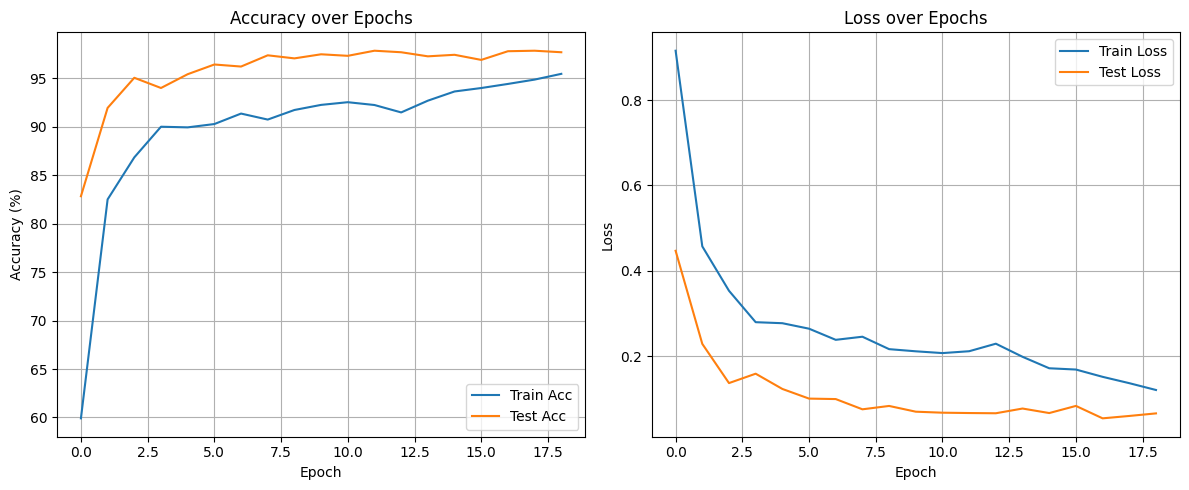

In [16]:
########## V I S U A L I Z E   T R A I N I N G ##########
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['test_acc'], label='Test Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

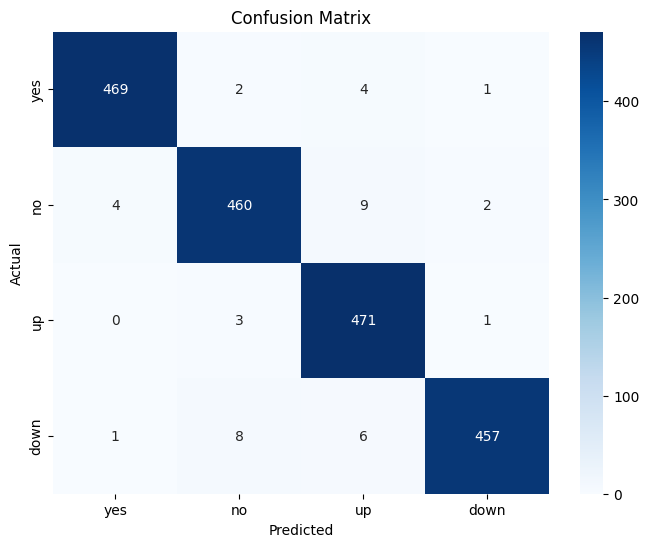

In [17]:
########## C O N F U S I O N   M A T R I X ##########
from sklearn.metrics import confusion_matrix
import seaborn as sns

def show_confusion_matrix(model):
    test_loader = DataLoader(KeywordDataset(test_paths, test_labels), batch_size=BATCH_SIZE, shuffle=False)
    mfcc_transform = torchaudio.transforms.MFCC(sample_rate=TARGET_SAMPLE_RATE, n_mfcc=40, melkwargs={"n_mels": 64}).to(DEVICE)
    
    all_preds = []
    all_targets = []
    
    model.eval()
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = mfcc_transform(inputs.to(DEVICE))
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.numpy())

    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

show_confusion_matrix(best_model)

In [18]:
########## F A I L E D   F I L E S ##########
def list_failed_files(model, limit=10):
    test_loader = DataLoader(KeywordDataset(test_paths, test_labels), batch_size=1, shuffle=False)
    mfcc_transform = torchaudio.transforms.MFCC(sample_rate=TARGET_SAMPLE_RATE, n_mfcc=40, melkwargs={"n_mels": 64}).to(DEVICE)
    
    failed = []
    model.eval()
    with torch.no_grad():
        for i, (inputs, target) in enumerate(test_loader):
            input_mfcc = mfcc_transform(inputs.to(DEVICE))
            output = model(input_mfcc)
            _, pred = torch.max(output, 1)
            
            if pred.item() != target.item():
                failed.append({
                    'path': test_paths[i],
                    'true': CLASSES[target.item()],
                    'pred': CLASSES[pred.item()]
                })
            if len(failed) >= limit: break
            
    print(f"{'True Label':<12} | {'Predicted':<12} | {'File Path'}")
    print("-" * 60)
    for f in failed:
        print(f"{f['true']:<12} | {f['pred']:<12} | {os.path.basename(f['path'])}")

list_failed_files(best_model)

True Label   | Predicted    | File Path
------------------------------------------------------------
no           | up           | 5c39594f_nohash_1.wav
yes          | up           | fd395b74_nohash_4.wav
no           | yes          | 9886d8bf_nohash_3.wav
down         | up           | e96a5020_nohash_0.wav
yes          | down         | 36de13e1_nohash_0.wav
no           | yes          | b59fa113_nohash_1.wav
yes          | up           | 3f2b358d_nohash_3.wav
down         | no           | 0bde966a_nohash_0.wav
down         | up           | 4a1e736b_nohash_4.wav
yes          | no           | 9a4d12fd_nohash_1.wav


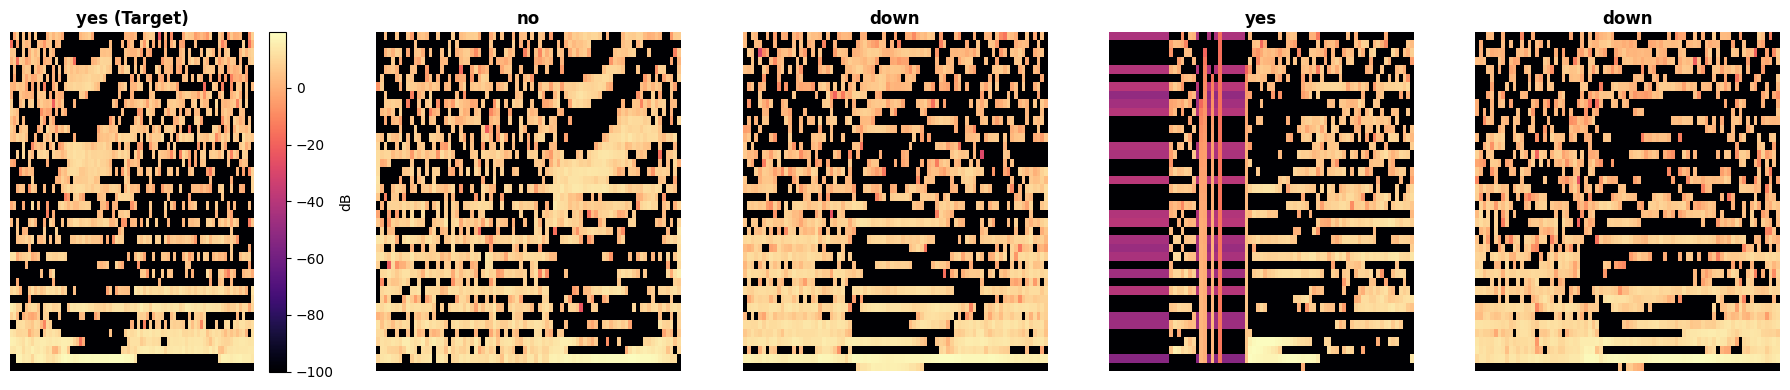

In [ ]:
########## P Y T O R C H   M E L   S P E C T R O G R A M ##########
import torchaudio.transforms as T

file_path = '../dataset/yes/00f0204f_nohash_0.wav'

if os.path.exists(file_path):
    # 1. Load Audio
    waveform, sample_rate = torchaudio.load(file_path)
    waveform = waveform[0] # Squeeze to 1D
    
    # 2. Define Transforms (Matching your friend's 128 mel bins)
    # Using standard speech params: n_fft=400, hop_length=160 (10ms step at 16k)
    mel_spectrogram_op = T.MelSpectrogram(
        sample_rate=sample_rate,
        n_fft=1024,
        win_length=None,
        hop_length=512,
        center=True,
        pad_mode="reflect",
        power=2.0,
        n_mels=128,
        norm='slaney',
        mel_scale='htk',
    )
    
    amplitute_to_db_op = T.AmplitudeToDB()

    # 3. Process
    mel_spec = mel_spectrogram_op(waveform)
    log_mel_spec = amplitute_to_db_op(mel_spec)

    # 4. Plot (Matching the inferno style)
    plt.figure(figsize=(10, 4))
    plt.imshow(log_mel_spec.numpy(), cmap='inferno', origin='lower', aspect='auto')
    
    plt.title(f'Mel Spektrogramm fuer {os.path.basename(file_path)}')
    plt.xlabel('Frames (Zeit)')
    plt.ylabel('Mel-Frequenzbänder')
    plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.show()
else:
    print(f"Datei {file_path} nicht gefunden. Bitte Pfad prüfen!")


## Check File Specs

In [20]:
########## C H E C K    F I L E    S P E C S ##########
def check_wav_specs(file_path):
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return
    with wave.open(file_path, 'rb') as wav_file:
        sample_rate = wav_file.getframerate()
        num_channels = wav_file.getnchannels()
        num_frames = wav_file.getnframes()

        print(f"Sample Rate: {sample_rate} Hz")
        print(f"Channels: {num_channels}")
        print(f"Frames: {num_frames}")
        print(f"Duration: {num_frames / sample_rate:.2f} seconds")

# Example Check
check_wav_specs("../dataset/yes/00f0204f_nohash_0.wav")

Sample Rate: 16000 Hz
Channels: 1
Frames: 16000
Duration: 1.00 seconds


In [21]:
########## T E S T   O N N X ##########
try:
    session = ort.InferenceSession(onnx_path)
    
    test_input = np.random.randn(1, 1, 40, 81).astype(np.float32)
    onnx_outputs = session.run(None, {'mfcc_input': test_input})
    
    print("SUCCESS: ONNX model loaded and verified with ONNX Runtime.")
    print(f"Output shape: {onnx_outputs[0].shape}")
except Exception as e:
    print(f"ERROR: ONNX verification failed: {e}")

SUCCESS: ONNX model loaded and verified with ONNX Runtime.
Output shape: (1, 4)
